# Saliency Plots

In [1]:
from dna_features_viewer import BiopythonTranslator, GraphicFeature, GraphicRecord
from dna_features_viewer.biotools import annotate_biopython_record
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob, os, yaml, sparse, itertools, subprocess, sys, pickle
import statsmodels.stats.api as sm

import Bio.SeqUtils
import Bio.Data
from Bio import SeqIO
from Bio.Seq import Seq

plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.titlepad'] = 10
import scipy.stats as st

# saliency_utils is in the utils_files directory
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), "utils"))
from saliency_utils import *
from inSilicoMut_utils import *
from data_utils import *

from sklearn.linear_model import LinearRegression

results_path = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"
vcf_dir = "/n/scratch3/users/s/sak0914/annotated_VCF"

solo_results = pd.read_excel("/home/sak0914/who-analysis/data/SOLO primary_STATA_ver18Feb2023.xlsx", sheet_name="Sheet1")
who_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_catalog_clean.csv")
who_variants_clean = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_catalog_clean.csv")
coll_2014 = pd.read_csv("/home/sak0914/who-analysis/data/coll2014_SNP_scheme.tsv", sep="\t")

df_mxf = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MXF/data_for_model.csv")
df_mxf_val = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MXF/validation_data_for_model.csv")

df_rif = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/data_for_model.csv")
df_rif_val = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/validation_data_for_model.csv")

h37Rv = SeqIO.read("/n/data1/hms/dbmi/farhat/Sanjana/GCF_000195955.2_ASM19595v2_genomic.gbff", "genbank")
h37Rv_genes = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/mycobrowser_h37rv_genes_v4.csv")

RIF_isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/isolate_variants.csv")

lineages = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/lineages.csv")
lineage_mat = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/lineage_matrix_Coll2014.csv", index_col=[0])
lineage_mat.shape

2023-04-21 10:08:01.500969: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-04-21 10:08:01.665975: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2023-04-21 10:08:01.666016: I tensorflow/compiler/xla/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2023-04-21 10:08:03.169038: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory
2023-

4411532


(11759, 62)

# Rifampicin

1 loci!
17 Cat 1 WHO catalog sites for RIF
2 Cat 1 WHO catalog sites not found
Sites not found: [761134 761156]
(7310, 5, 7826, 1)


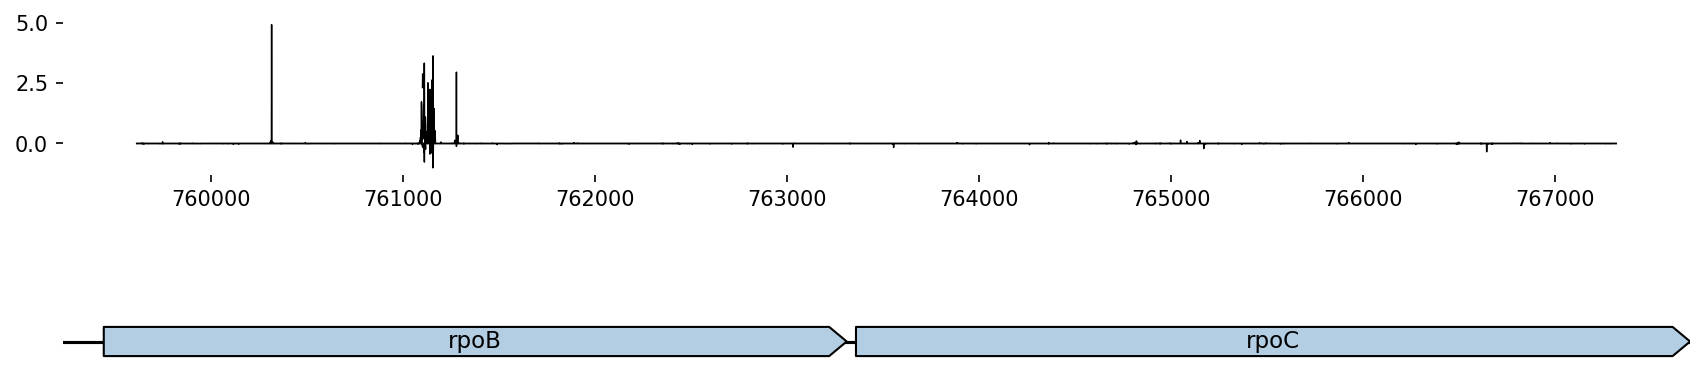

In [2]:
rif_rpoBC_df, rif_rpoBC_seqDict = generate_saliency_plots("RIF",
                                                          os.path.join(results_path, "RIF_rpoBC"),
                                                          ["rpoBC"],
                                                          plot_thresh=10,
                                                          cat_to_check=["1"],
                                                          binary=False,
                                                          save=True,
                                                          significance=False,
                                                          sig_thresh=0.05
                                                         )


rif_rpoBC_scores = sparse.load_npz(os.path.join(results_path, "RIF_rpoBC/saliency/quant/genetic_scores_unpooled_nuc.npy.npz")).todense()
# num_samples x 5 nucleotides x longest_locus x num_loci
print(rif_rpoBC_scores.shape)

In [5]:
rif_rpoBC_df.query("Max > 3")

,Gene,Pos,Max,Min,WHO,Coll_2014,Freschi_2020
731,rpoBC,760314.0,4.922290,0.000000,1,0,0
1550,rpoBC,761109.0,3.316183,-0.340098,1,0,0
1551,rpoBC,761110.0,3.327429,-0.768517,1,0,0
1596,rpoBC,761155.0,3.628988,0.000000,1,0,0


In [7]:
who_variants.query("drug=='RIF' & genome_index.str.contains('760314')")

,drug,genome_index,confidence,mutation
61,RIF,760314,1) Assoc w R,rpoB_p.Val170Phe


In [10]:
rif_rpoBC_df.query("Max_Sig == 1 & Max > 3")

,Gene,Pos,Max,Min,Max_Sig,Min_Sig,WHO,Coll_2014,Freschi_2020
731,rpoBC,760314.0,4.111588,0.000000,1.0,0.0,1,0,0
1535,rpoBC,761100.0,3.048757,0.000000,1.0,0.0,1,0,0
1551,rpoBC,761110.0,3.804006,-0.823734,1.0,1.0,1,0,0
1580,rpoBC,761139.0,3.284555,-1.018386,1.0,1.0,1,0,0
1596,rpoBC,761155.0,3.681476,0.000000,1.0,0.0,1,0,0


In [16]:
rif_rpoBC_df.query("Max_Sig == 1 & Max > 1")

,Gene,Pos,Max,Min,Max_Sig,Min_Sig,WHO,Coll_2014,Freschi_2020
731,rpoBC,760314.0,4.111588,0.000000,1.0,0.0,1,0,0
1524,rpoBC,761095.0,2.248429,0.000000,1.0,0.0,1,0,0
1535,rpoBC,761100.0,3.048757,0.000000,1.0,0.0,1,0,0
1536,rpoBC,761101.0,2.704630,-0.188917,1.0,1.0,1,0,0
1538,rpoBC,rpoBC_46,2.354957,0.000000,1.0,0.0,0,0,0
1539,rpoBC,rpoBC_47,2.713095,0.000000,1.0,0.0,0,0,0
1550,rpoBC,761109.0,2.923858,-0.206026,1.0,1.0,1,0,0
1551,rpoBC,761110.0,3.804006,-0.823734,1.0,1.0,1,0,0
1569,rpoBC,761128.0,2.796457,-0.253920,1.0,1.0,1,0,0
1580,rpoBC,761139.0,3.284555,-1.018386,1.0,1.0,1,0,0


1 loci!
17 Cat 1 WHO catalog sites for RIF
2 Cat 1 WHO catalog sites not found
Sites not found: [761134 761156]
(7310, 5, 7826, 1)


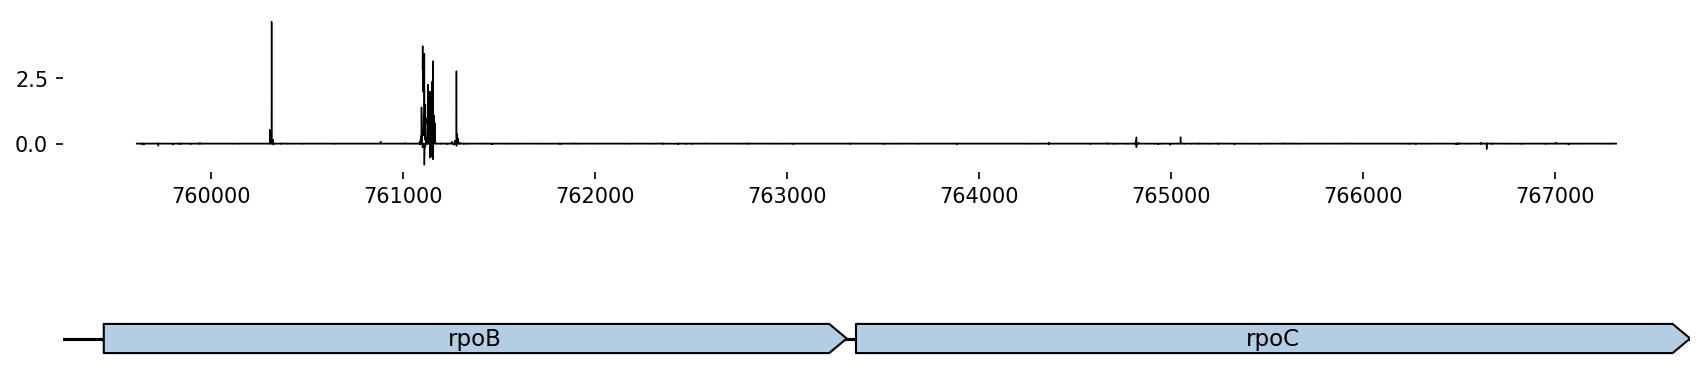

In [3]:
rif_rpoBC_lineage_df, _ = generate_saliency_plots("RIF",
                                                  os.path.join(results_path, "RIF_rpoBC_lineage"),
                                                  ["rpoBC"],
                                                  plot_thresh=10,
                                                  cat_to_check=["1"],
                                                  binary=False,
                                                  save=True,
                                                  significance=False
                                                 )

rif_rpoBC_lineage_scores = sparse.load_npz(os.path.join(results_path, "RIF_rpoBC_lineage/saliency/quant/genetic_scores_unpooled_nuc.npy.npz")).todense()
print(rif_rpoBC_lineage_scores.shape)

# rif_rpoBC_seqDict["rpoBC"].to_csv("/home/sak0914/MtbQuantCNN/analysis/Rifampicin/rpoBC_seqdf.csv")

In [15]:
rpoBC_seqdf = rif_rpoBC_seqDict["rpoBC"]
rif_rpoBC_lineage_df.query("Min_Sig == 1 | Max_Sig==1").shape

(536, 9)

In [61]:
def get_scores_by_nuc(pos, seq_df, scores_matrix):
    
    search_idx = list(seq_df.columns).index(pos)#rif_rpoBC_lineage_df.query("Pos==@pos").index.values[0]
    ref = seq_df.loc["MT_H37Rv", pos]
    print(ref)
    
    return dict(zip(BASE_TO_COLUMN.keys(), np.max(scores_matrix[:, :, search_idx, 0], axis=0))), dict(zip(BASE_TO_COLUMN.keys(), np.min(scores_matrix[:, :, search_idx, 0], axis=0)))

# Are there Different Alleles with Different Scores at Sites where both Max and Min are Significant

In [ ]:
RIF_max_min_significant = rif_rpoBC_df.query("(Max > 0 & Max_Sig==1) & (Min < 0 & Min_Sig==1)")

In [ ]:
pos = 761154
get_scores_by_nuc(pos, rpoBC_seqdf, rif_rpoBC_scores)

T


({'A': 0.0, 'C': 0.6363485, 'T': 0.57845545, 'G': 0.40106404, '-': 0.0},
 {'A': -0.5066079, 'C': 0.0, 'T': -1.47051, 'G': -0.79187685, '-': 0.0})

In [ ]:
sum(get_scores_by_nuc(pos, rpoBC_seqdf, rif_rpoBC_scores)[1].values())

T


-2.7689947485923767

In [ ]:
rpoBC_seqdf[pos].value_counts()

C    9119
T      13
G       3
N       2
A       1
Name: 759940.0, dtype: int64

In [ ]:
who_variants.query("genome_index.str.contains('761154')")

,drug,genome_index,confidence,mutation
66,RIF,"761154,761155",1) Assoc w R,rpoB_p.Ser450Leu
377,RIF,"761154,761155",2) Assoc w R - Interim,rpoB_p.Ser450Met
390,RIF,"761154,761155",2) Assoc w R - Interim,rpoB_p.Ser450Gly
400,RIF,"761154,761155",2) Assoc w R - Interim,rpoB_p.Ser450Gln
443,RIF,"761154,761155",2) Assoc w R - Interim,rpoB_p.Ser450Val


# Moxifloxacin

In [21]:
# mxf_gyrBA_df, mxf_gyrBA_seqDict = generate_saliency_plots("MXF",
#                                                           os.path.join(results_path, "MXF_gyrBA"),
#                                                           ["gyrBA"],
#                                                           plot_thresh=0.1,
#                                                           cat_to_check=["1", "2"],
#                                                           binary=False,
#                                                           save=True,
#                                                           significance=True
#                                                          )

# mxf_gyrBA_df.to_csv("/home/sak0914/MtbQuantCNN/analysis/Moxifloxacin/gyrBA_saliency_results.csv", index=False)
# mxf_gyrBA_seqDict["gyrBA"].to_csv("/home/sak0914/MtbQuantCNN/analysis/Moxifloxacin/gyrBA_seqdf.csv")

In [22]:
# mxf_gyrBA_lineage_df, _ = generate_saliency_plots("MXF",
#                                                   os.path.join(results_path, "MXF_gyrBA_lineage"),
#                                                   ["gyrBA"],
#                                                   plot_thresh=0.1,
#                                                   cat_to_check=["1", "2"],
#                                                   binary=False,
#                                                   save=True,
#                                                   significance=True
#                                                  )

# Lineage Saliency Plots

In [8]:
def generate_lineage_saliency_plot(drug, out_dir, df_phenos, binary_thresh, binary=False, save_title=None):
    
    sig_thresh = 0.05
    df_phenos["log2-MIC"] = np.log2(df_phenos[f"{drug}_midpoint"])
    
    # make lineage matrix. Do this before getting only the train or test set so that all lineages are there
    #lineages = get_lineages_matrix(df_phenos)
    lineages = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/lineage_matrix_Coll2014.csv", index_col=[0])
    lineages.columns = lineages.columns.astype(int)
    assert len(np.unique(lineages.values)) == 2

    # get only the training or testing set and subset the lineage matrix too
    lineages = lineages.loc[df_phenos["ROLLINGDB_ID"]]
    
    if binary:
        saliency_dir = os.path.join(out_dir, "saliency/binary")
    else:
        saliency_dir = os.path.join(out_dir, "saliency/quant")
        
    # get lineage scores for the primary model
    lineage_scores = np.load(os.path.join(saliency_dir, "lineage_scores.npy"))
    lineage_max = lineage_scores.max(axis=0)
    lineage_min = lineage_scores.min(axis=0)
    
    # create a dataframe with lineages, scores, and average log-MIC of isolates
    lineage_scores_df = pd.DataFrame({"position": lineages.columns, "Max": lineage_max, "Min": lineage_min})
    lineage_scores_df = lineage_scores_df.merge(coll_2014[["#lineage", "position"]], on="position")
    lineage_scores_df.rename(columns={"#lineage":"Lineage"}, inplace=True)
    lineage_scores_df["Lineage"] = [val.replace("lineage", "") for val in lineage_scores_df["Lineage"].values]
    
    # add log2-MIC to get averaged per lineage later
    lineages = lineages.merge(df_phenos[["ROLLINGDB_ID", "log2-MIC"]].set_index("ROLLINGDB_ID"), left_index=True, right_index=True)

    # get permutation score results
    lineage_scores_paths = glob.glob(os.path.join(saliency_dir, "permutation_test/lineage_scores*.npy"))
    assert len(lineage_scores_paths) == 10
    
    lineage_permute_max = [pd.Series(np.load(scores_path).max(axis=0)) for scores_path in lineage_scores_paths]
    lineage_permute_max = pd.concat(lineage_permute_max, axis=1).values

    lineage_permute_min = [pd.Series(np.load(scores_path).min(axis=0)) for scores_path in lineage_scores_paths]
    lineage_permute_min = pd.concat(lineage_permute_min, axis=1).values
        
    # get p-values
    max_pvals = []
    min_pvals = []

    # get p-values from the permutation test
    for i, row in lineage_scores_df.iterrows():
        lineage_scores_df.loc[i, "Max_pval"] = np.mean(lineage_permute_max[i, :] > lineage_max[i])
        lineage_scores_df.loc[i, "Min_pval"] = np.mean(lineage_permute_min[i, :] < lineage_min[i])

    # add FDR correction
    _, max_bh_pvals, _, _ = sm.multipletests(lineage_scores_df["Max_pval"], method='fdr_bh', is_sorted=False, returnsorted=False)
    _, min_bh_pvals, _, _ = sm.multipletests(lineage_scores_df["Min_pval"], method='fdr_bh', is_sorted=False, returnsorted=False)

    lineage_scores_df["BH_Max_pval"] = max_bh_pvals
    lineage_scores_df["BH_Min_pval"] = min_bh_pvals

    assert len(lineage_scores_df.query("Max_pval > BH_Max_pval")) == 0
    assert len(lineage_scores_df.query("Min_pval > BH_Min_pval")) == 0

    for i, row in lineage_scores_df.iterrows():

        # add average log2-MIC of isolates with that SNP
        log2_MIC = lineages.loc[lineages[row["position"]]==1]["log2-MIC"].mean()
        lineage_scores_df.loc[i, "log2-MIC"] =log2_MIC
    
        # then perform a hypothesis test for MIC enrichment (greater or less than the mean)
        pos, lineage = str(row["position"]), row["Lineage"]

        isolates_in_lineage = lineage_mat.loc[df_phenos["ROLLINGDB_ID"].values].loc[lineage_mat[pos]==1].index.values

        if len(isolates_in_lineage) > 0:

            if log2_MIC > np.log2(binary_thresh):
                alt = "greater"
            else:
                alt = "less"

            mu_stat, mu_pval = st.mannwhitneyu(df_phenos.query("ROLLINGDB_ID in @isolates_in_lineage")[f"{drug}_midpoint"].values, 
                                               df_phenos[f"{drug}_midpoint"].values,
                                               alternative=alt,
                                              )

            lineage_scores_df.loc[i, "MIC_enrich_pval"] = mu_pval
        
        else:
            lineage_scores_df.loc[i, "MIC_enrich_pval"] = 0.5
        
    _, mic_bh_pvals, _, _ = sm.multipletests(lineage_scores_df["MIC_enrich_pval"], method='fdr_bh', is_sorted=False, returnsorted=False)
    lineage_scores_df["BH_MIC_enrich_pval"] = mic_bh_pvals

    significant_lineages = lineage_scores_df.query("(BH_Max_pval < @sig_thresh & Max > 0) | (BH_Min_pval < @sig_thresh & Min < 0)").reset_index(drop=True)
    print(f"{len(significant_lineages)}/{len(lineage_scores_df)} lineages are significant")
        
    # combine Max and Min scores, into a single array, depending on the site
    for i, row in significant_lineages.iterrows():

        if row["BH_Max_pval"] < sig_thresh:

            # if Max is significant, but not Min
            if row["BH_Min_pval"] >= sig_thresh:
                significant_lineages.loc[i, "plot_score"] = row["Max"]

            # if both are significant, take the average
            else:
                significant_lineages.loc[i, "plot_score"] = np.mean([row["Max"], row["Min"]])

        elif row["BH_Min_pval"] < sig_thresh:
            significant_lineages.loc[i, "plot_score"] = row["Min"]
            
#     significant_lineages = significant_lineages.query("BH_MIC_enrich_pval < @sig_thresh")
#     print(f"{len(significant_lineages)}/{len(lineage_scores_df)} lineages have MICs significantly different from the average")
                    
    # fit a linear regression
    X = significant_lineages["plot_score"].values.reshape(-1, 1)
    y = significant_lineages["log2-MIC"]

    linReg = LinearRegression(fit_intercept=True)
    linReg.fit(X, y)
    yhat = linReg.predict(X)
    
    fig, ax = plt.subplots()
    sns.scatterplot(data=significant_lineages, x="plot_score", y="log2-MIC", ax=ax, s=25)

    label_thresh = 0
    for i, row in significant_lineages.iterrows():

        if row["Max"] > label_thresh or row["Min"] < -label_thresh:
            
            # manual changes to prevent labels from covering each other up
            if row["Lineage"] == "BOV":
                ax.text(row["plot_score"] + 0.03, row["log2-MIC"] - 0.2, row["Lineage"], color='black', fontsize=6)
            elif row["Lineage"] == "1.1.1.1":
                ax.text(row["plot_score"] - 0.09, row["log2-MIC"] + 0.1, row["Lineage"], color='black', fontsize=6)
            else:
                ax.text(row["plot_score"] + 0.03, row["log2-MIC"] + 0.05, row["Lineage"], color='black', fontsize=6)

    plt.plot(np.squeeze(X), yhat, color="tomato", linewidth=0.5, label=f"y = {np.round(linReg.intercept_, 2)} + {np.round(linReg.coef_[0], 2)}x")

    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)
    
    plt.legend(fontsize=8, loc="lower right")
    plt.xlabel("\nSaliency Score", fontsize=9)
    plt.ylabel("Average log2-MIC\n", fontsize=9)
    sns.despine()
    
    spearman_results = st.spearmanr(np.squeeze(X), y)
    
    plt.title(f"{drug} Lineage Model, Spearman R = {np.round(spearman_results[0], 2)}", fontsize=10)
    
    # print(f"R^2: {linReg.score(X, y)}")
    print(f"Spearman pval: {spearman_results[1]}")
    
    if save_title is None:
        plt.show()
    else:
        plt.savefig(save_title, dpi=300)
        
    return significant_lineages

In [9]:
# generate_lineage_saliency_plot("MXF", "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/MXF_gyrBA_lineage", 
#                                #save_title="/home/sak0914/Figures/MXF/lineage_scatter.png"
#                               )

In [10]:
RIF_sig_lineage_scores_df = generate_lineage_saliency_plot("RIF", 
                                                           "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/RIF_rpoBC_lineage", 
                                                           df_rif,
                                                           0.5,
                                                           save_title="../analysis/Rifampicin/lineage_scatter.png"
                                                          )

AssertionError: 

In [46]:
RIF_sig_lineage_scores_df.sort_values("plot_score").to_csv("test.csv", index=False)

# Is MIC Significantly Elevated in Certain Lineages

In [299]:
RIF_sig_lineage_scores_df.query("Lineage in ['4.2.1', '2.2.1']")

,position,Max,Min,Lineage,Max_pval,Min_pval,BH_Max_pval,BH_Min_pval,log2-MIC,MIC_enrich_pval,BH_MIC_enrich_pval,plot_score
3,783601,-0.0,-0.393883,4.2.1,0.1,0.0,0.344444,0.0,0.510582,0.000498,0.001029,-0.393883
4,797736,-0.0,-0.223559,2.2.1,0.4,0.0,0.590476,0.0,-0.853869,0.457839,0.535586,-0.223559


In [287]:
RIF_sig_lineage_scores_df.query("BH_MIC_enrich_pval < 0.05")

,position,Max,Min,Lineage,Max_pval,Min_pval,BH_Max_pval,BH_Min_pval,log2-MIC,MIC_enrich_pval,BH_MIC_enrich_pval,plot_score
1,346693,0.741299,0.000000,2.2.2,0.0,0.6,0.000000,0.676364,1.292509,6.141254e-16,4.759472e-15,0.741299
2,514245,0.691994,0.000000,4.1.1,0.0,0.6,0.000000,0.676364,-0.111073,8.549601e-06,2.304675e-05,0.691994
6,1882180,-0.000000,-0.669186,BOV_AFRI,0.6,0.0,0.641379,0.000000,-4.199761,5.087022e-06,1.470124e-05,-0.669186
7,2831482,-0.000000,-0.655679,BOV,0.6,0.0,0.641379,0.000000,-4.199761,5.087022e-06,1.470124e-05,-0.655679
8,3021283,-0.000000,-0.317414,1.1.1,0.3,0.0,0.581250,0.000000,-4.897060,2.157014e-53,4.457829e-52,-0.317414
9,3216553,-0.000000,-0.364554,1.1.1.1,0.5,0.0,0.620000,0.000000,-4.959214,9.729504e-46,1.508073e-44,-0.364554
12,4260268,0.444209,0.000000,4.6.1,0.0,0.9,0.000000,0.914754,1.988988,1.512227e-06,5.515181e-06,0.444209
13,4404247,-0.000000,-0.363112,1.1,0.5,0.0,0.620000,0.000000,-4.045164,1.138472e-65,7.058529e-64,-0.363112


In [ ]:
# nice! does not co-occur with canonical gyrBA mutations
plot_variant_mics("gyrBA", 7566, moxi_gyrBA_seq_dict, df_moxi, isolates_with_gyrBA_mut, title="../Figures/gyrBA_7566_mic_dist.png")

In [ ]:
# too few isolates: only 5 with gyrBA or the variant at all. Also not convincing with the shift
# plot_variant_mics("gyrBA", 7521, moxi_gyrBA_seq_dict, df_moxi, isolates_with_gyrBA_mut)

In [ ]:
# not super convincing. 22 total isolates, but gyrBA variants seem to be higher
# 6735, 6737, 6749
plot_variant_mics("gyrBA", 6735, moxi_gyrBA_seq_dict, df_moxi, isolates_with_gyrBA_mut)

In [ ]:
plot_variant_mics("gyrBA", 8164, moxi_gyrBA_seq_dict, df_moxi, isolates_with_gyrBA_mut, title="../Figures/gyrBA_8164_mic_dist.png")

# Moxifloxacin Multiloci Models

In [ ]:
# moxi_gyrBA_6Loci_df, moxi_gyrBA_6Loci_seq_dict = generate_saliency_plots("config_moxi_6Loci.yaml",
#                                                              ["MXF"],
#                                                              cat_to_check=["1", "2"],
#                                                              binary=False,
#                                                              isolate_variants_df=None,
#                                                              num_bootstrap=1, 
#                                                              save=True
#                                                             )

# Bedaquiline

In [ ]:
# bdq_no_lineage_df, bdq_no_lineage_seq_dict = generate_saliency_plots("config_bdq_old.yaml",
#                                                              ["BDQ"],
#                                                              cat_to_check=["1", "2"],
#                                                              binary=False,
#                                                              isolate_variants_df=None,
#                                                              num_bootstrap=1, 
#                                                              save=True
#                                                             )

# Rifampicin

In [ ]:
rif_rpoBC_df, rif_rpoBC_seq_dict = generate_saliency_plots("config_rif.yaml",
                                                             ["RIF"],
                                                             cat_to_check=["1", "2"],
                                                             binary=False,
                                                             isolate_variants_df=None,
                                                             num_bootstrap=1000, 
                                                             save=True
                                                            )

In [ ]:
who_single_drug = who_variants.query("drug=='RIF'")

who_pos = who_single_drug["genome_index"].str.split(",", expand=True)
who_pos.columns = ["pos1", "pos2"]

who_single_drug = pd.concat([who_single_drug, who_pos], axis=1).reset_index(drop=True)
print(who_single_drug.shape)

In [ ]:
for i, row in who_single_drug.iterrows():
    
    if not pd.isnull(row["pos2"]):
        
        # duplicate the row and make pos1 to pos2 in the duplicate
        add_row = who_single_drug.iloc[i, :]
        add_row["pos1"] = row["pos2"]
        
        who_single_drug = pd.concat([who_single_drug, pd.DataFrame(add_row).T], axis=0)
        
who_single_drug = who_single_drug.reset_index(drop=True)
del who_single_drug["pos2"]
del who_single_drug["genome_index"]
print(who_single_drug.shape)
who_single_drug.rename(columns={"pos1": "Pos"}, inplace=True)
who_single_drug["Pos"] = who_single_drug["Pos"].astype(float).astype(object)

In [ ]:
# get all sites with positive saliency scores
rif_resistance_analysis = rif_rpoBC_df.query("Max > 0 & max_pVal < 0.05").merge(who_single_drug, on="Pos", how="outer").sort_values("Max", ascending=False)

rif_resistance_analysis = rif_resistance_analysis.query("gene in ['rpoB', 'rpoC']").reset_index(drop=True)

del rif_resistance_analysis["Unnamed: 0"]
print(rif_resistance_analysis.shape)

#new_pos = rif_resistance_analysis.query("confidence in ['3) Uncertain significance', '5) Not assoc w R']")
new_pos = rif_resistance_analysis.loc[(~pd.isnull(rif_resistance_analysis["Max"])) & (rif_resistance_analysis["confidence"] == '3) Uncertain significance')]

print(new_pos.shape)

In [ ]:
for i, row in new_pos.iterrows():
    
    ref = rif_rpoBC_seq_dict["rpoBC"].loc["MT_H37Rv", row["Pos"]]
    alt = rif_rpoBC_seq_dict["rpoBC"][row["Pos"]] != ref
    new_pos.loc[i, "Num_Isolates"] = sum(alt)
    
# new_pos = new_pos.query("Num_Isolates > 5").reset_index(drop=True)
new_pos["Num_Isolates"] = new_pos["Num_Isolates"].astype(int) 
print(new_pos.shape)

In [ ]:
new_pos.sort_values(["Num_Isolates", "Max"], ascending=False)

In [ ]:
drug = "RIF"
locus = "rpoBC"
pos = 761880.0
cc = 0.5

for _, row in new_pos.drop_duplicates("Pos").sort_values(["Num_Isolates", "Max"], ascending=False).iterrows():
    plot_variant_mics(drug, locus, row["Pos"], rif_rpoBC_seq_dict, df_rif, isolates_with_rpoBC_mut, cc, title=None)

In [ ]:
# rif_rpoABC_df, rif_rpoABC_seq_dict = generate_saliency_plots("config_rif_multiLoci.yaml",
#                                                              ["RIF"],
#                                                              cat_to_check=["1", "2"],
#                                                              binary=False,
#                                                              isolate_variants_df=None,
#                                                              num_bootstrap=1, 
#                                                              save=True
#                                                             )

In [ ]:
# drug = "RIF"
# locus = "rpoA"
# pos = 3878575.0
# cc = 0.5

# plot_variant_mics(drug, locus, pos, rif_rpoABC_seq_dict, df_rif, isolates_with_rpoBC_mut, cc, title=None)

In [ ]:
# rif_rpoABC_Rv2752c_df, rif_rpoABC_Rv2752c_seq_dict = generate_saliency_plots("config_rif.yaml",
#                                                                              ["RIF"],
#                                                                              cat_to_check=["1", "2"],
#                                                                              binary=False,
#                                                                              isolate_variants_df=None,
#                                                                              num_bootstrap=1, 
#                                                                              save=True
#                                                                             )

In [ ]:
# rif_rpoBC_lineage_df, rif_rpoBC_lineage_seq_dict = generate_saliency_plots("config_rif_lineage.yaml",
#                                                              ["RIF"],
#                                                              cat_to_check=["1", "2"],
#                                                              binary=False,
#                                                              isolate_variants_df=None,
#                                                              num_bootstrap=1, 
#                                                              save=True
#                                                             )

In [ ]:
def two_sample_mean_bootstrap(variant_mics, no_variant_mics, num_bootstrap=1000):
    '''
    Want log2(fold change) > 1. 
    '''
    
    if len(variant_mics) > 0 and len(no_variant_mics) > 0:
        bs_res = []
        #test_stat = np.mean(variant_mics) - np.mean(no_variant_mics)
        test_stat = np.log2(np.mean(variant_mics) / np.mean(no_variant_mics))

        # do bootstrapping of difference in means. Randomly sample isolates from the two groups, then compute the mean difference in MIC between them
        for _ in range(num_bootstrap):

            # draw bootstraps
            variant_sample = np.random.choice(variant_mics, np.max([len(variant_mics), num_bootstrap]), replace=True)
            no_variant_sample = np.random.choice(no_variant_mics, np.max([len(no_variant_mics), num_bootstrap]), replace=True)

            # get the test statistic and add it to a running list
            #stat = np.mean(variant_sample) - np.mean(no_variant_sample)
            stat = np.log2(np.mean(variant_sample) / np.mean(no_variant_sample))
            bs_res.append(stat)
    else:
        test_stat = np.nan
        bs_res = np.ones(num_bootstrap) * np.nan
        
    return test_stat, np.array(bs_res)

In [ ]:
def plot_variant_mics(drug, locus, variant, mat_seq_dict, df_phenos, isolates_with_canonical_mut, cc, title=None):
    
    # sns.color_palette("Set2").as_hex()[0]
    palette = "Set1"
    color_dict = {"no variants": sns.color_palette(palette).as_hex()[-1], 
                  "variant only": sns.color_palette(palette).as_hex()[1],
                  "canonical mut only": sns.color_palette(palette).as_hex()[4],
                  "canonical mut + variant": sns.color_palette(palette).as_hex()[0]
                 }
        
    ref = mat_seq_dict[locus].loc["MT_H37Rv", variant]
    isolates_with_variant = mat_seq_dict[locus].loc[mat_seq_dict[locus][variant] != ref, variant].index.values
    
    isolates_both = list(set(isolates_with_canonical_mut).intersection(isolates_with_variant))
    isolates_variant_only = list(set(isolates_with_variant) - set(isolates_with_canonical_mut))
    isolates_canonical_only = list(set(isolates_with_canonical_mut) - set(isolates_with_variant))
    
    isolates_nothing_1 = list(set(df_phenos["ROLLINGDB_ID"]) - set(isolates_both) - set(isolates_variant_only) - set(isolates_canonical_only))
    isolates_nothing_2 = list(set(df_phenos["ROLLINGDB_ID"]) - set(isolates_with_canonical_mut) - set(isolates_with_variant))
    assert len(isolates_nothing_1) == len(isolates_nothing_2) == len(set(isolates_nothing_1).intersection(isolates_nothing_2))
        
    df_phenos.loc[df_phenos["ROLLINGDB_ID"].isin(isolates_nothing_1), "Variant"] = 'no variants'
    df_phenos.loc[df_phenos["ROLLINGDB_ID"].isin(isolates_both), "Variant"] = 'canonical mut + variant'
    df_phenos.loc[df_phenos["ROLLINGDB_ID"].isin(isolates_variant_only), "Variant"] = 'variant only'
    df_phenos.loc[df_phenos["ROLLINGDB_ID"].isin(isolates_canonical_only), "Variant"] = 'canonical mut only'
                            
    # print("There are no isolates without canonical variants, but with the variant of interest")
    if ~('variant only' not in df_phenos["Variant"].value_counts().index.values):
        df_phenos["log-MIC"] = np.log(df_phenos[f"{drug}_midpoint"])
        if (len(df_phenos.query("Variant == 'variant only'")) > 0) & (len(df_phenos.loc[(df_phenos["Variant"] == 'variant only') & (df_phenos[f"{drug}_midpoint"] > cc)]) > 1):
            print(df_phenos.groupby("Variant")[f"{drug}_midpoint"].mean())
            print(df_phenos["Variant"].value_counts())

            fig, ax = plt.subplots(1, 1, figsize=(12, 4))
            g = sns.histplot(data=df_phenos, x="log-MIC", hue='Variant', 
                             stat='probability', common_norm=False, multiple='dodge', 
                             hue_order=["no variants", 'canonical mut only', "variant only", 'canonical mut + variant'], 
                             palette=color_dict, ax=ax)

            plt.xlabel("MIC (μg/mL)")
            plt.xticks(ticks=ax.get_xticks(), labels=np.round(np.exp(ax.get_xticks()), 2).astype(str))
            ax.set_title(f"{drug} MIC Distribution for Variants at Position {int(variant)}")

            sns.move_legend(ax, "upper left", title=None)
            sns.despine()

            if title is None:
                plt.show()
            else:
                plt.savefig(title, dpi=300)
        # else:
        #     print(f"There are no isolates with only a variant at {variant}")

In [ ]:
def filter_saliencies(saliency_df, mat_seq_dict, drug, df_phenos):
    
    # get positions with non-zero scores
    nonZero = saliency_df.query("Max != 0 | Min != 0")
    
    # find the number of isolates with 
    for i, row in nonZero.iterrows():
        df = mat_seq_dict[row["Gene"]]
        if len(df[row["Pos"]].unique()) > 1:
            nonZero.loc[i, "Variant"] = 1
        else:
            nonZero.loc[i, "Variant"] = 0

    nonZero_analysis = nonZero.query("Variant == 1").sort_values("Max", ascending=False)
    
    for i, row in nonZero_analysis.iterrows():

        gene = row["Gene"]
        pos = row["Pos"]
        ref = mat_seq_dict[gene].loc["MT_H37Rv", pos]

        isolates_with_variant = mat_seq_dict[gene].loc[mat_seq_dict[gene][pos] != ref, pos].index.values

        if len(isolates_with_variant) >= 5:
            phenos_variant = df_phenos.query("ROLLINGDB_ID in @isolates_with_variant")[f"{drug}_midpoint"].values
            phenos_no_variant = df_phenos.query("ROLLINGDB_ID not in @isolates_with_variant")[f"{drug}_midpoint"].values

            stat, bootstrap_reps = two_sample_mean_bootstrap(phenos_variant, phenos_no_variant, num_bootstrap=100)
            lower, upper = np.percentile(bootstrap_reps, q=[2.5, 97.5])

            nonZero_analysis.loc[i, ["log2_FC", "log2_FC_LB", "log2_FC_UB"]] = stat, lower, upper
        else:
            nonZero_analysis.loc[i, ["log2_FC", "log2_FC_LB", "log2_FC_UB"]] = np.nan, np.nan, np.nan
            
    return nonZero_analysis.dropna(axis=0, how="any")

In [ ]:
df_moxi.query("gyrBA_mut==0").to_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MOXI/20220929_no_gyrBACanonicalMut.csv", index=False)

In [ ]:
test = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MOXI/20220929_no_gyrBACanonicalMut.csv")

In [ ]:
test.shape

In [ ]:
4819/(4819+1198)

In [ ]:
1198/(4819+1198)

In [ ]:
df_moxi.query("gyrBA_mut==0").groupby("category")["MOXI_midpoint"].mean()

In [ ]:
df_moxi.query("ROLLINGDB_ID not in @isolates_with_gyrBA_mut").MOXI_midpoint.max()

In [ ]:
df_moxi.query("ROLLINGDB_ID in @isolates_with_gyrBA_mut").MOXI_midpoint.max()

In [ ]:
#plot_variant_mics("Rv3361c_Rv3365c", 3774261, moxi_4Loci_seq_dict, df_moxi, isolates_with_gyrBA_mut)

In [ ]:
#plot_variant_mics("Rv3561_Rv3565", 4005357.0, moxi_4Loci_seq_dict, df_moxi, isolates_with_gyrBA_mut)

In [ ]:
#plot_variant_mics("Rv3561_Rv3565", 4004893.0, moxi_4Loci_seq_dict, df_moxi, isolates_with_gyrBA_mut)

In [ ]:
moxi_isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MOXI/isolate_variants.csv")

# Moxifloxacin Multi-Loci

In [ ]:
locus_list = ['gyrBA', 'Rv0981_Rv0984', 'Rv3361c_Rv3365c', 'Rv3561_Rv3565'] 
moxi_4loci_df, moxi_4Loci_seq_dict = generate_saliency_plots("MOXI", 
                                                                 locus_list, 
                                                                 "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/20220928_moxi_4Loci", 
                                                                 "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/fastas", 
                                                                 ["MXF"], 
                                                                 "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MOXI/20220902_data_clean.csv",
                                                                 cat_to_check=["1", "2"],
                                                                 isolate_variants_df=None,
                                                                 num_bootstrap=1000, 
                                                                 save=False
                                                                )

In [ ]:
locus_list = ['gyrBA', 'Rv0981_Rv0984', 'Rv2836c_Rv2837c', 'Rv3361c_Rv3365c', 'Rv0014c_Rv0015c', 'arfABC', 'phoPR', 'mbtK', 'Rv3561_Rv3565', 'stp', 'Rv0053_Rv0058', 'ligD_Rv0939'] 
# definitely remove: phoPR, stp, mbtK, Rv2836c_Rv2837c (dinF)
# next tier: arfABC, Rv0014c_Rv0015c

# generally good agreement between low saliency and not much contribution to MAE reduction

moxi_12loci_df, moxi_12Loci_seq_dict = generate_saliency_plots("MOXI", 
                                                                 locus_list, 
                                                                 "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/20220907_moxi_12Loci", 
                                                                 "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/fastas", 
                                                                 ["MXF"], 
                                                                 "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MOXI/20220902_data_clean.csv",
                                                                 cat_to_check=["1", "2"],
                                                                 isolate_variants_df=None,
                                                                 num_bootstrap=1000, 
                                                                 save=False
                                                                )

# Analysis of Positions from Multi-Gene Model

In [ ]:
def validate_with_MIC_dist(locus, variant_col, mat_seq_dict, df_phenos, isolates_with_gyrBA_mut, num_bootstrap=1000):
    
    # check for significantly positive confidence intervals for all 3 groups -- isolates with canonical gyrBA mutations, isolates without, and all isolates
    ci_no_gyrBA, ci_gyrBA = plot_variant_mics(locus, variant_col, mat_seq_dict, df_phenos, isolates_with_gyrBA_mut, num_bootstrap=num_bootstrap, plot=False)
    #ci_all = plot_variant_mics_full_dist(locus, variant_col, mat_seq_dict, df_phenos, plot=False)
    
    # if at least one of them is significantly positive, keep that variant    
    cis_lst = [ci_no_gyrBA, ci_gyrBA]
    
    sig_bool = False
    for ci in cis_lst:
        
        if ci[0] > 0 and ci[1] > 0:
            sig_bool = True
            break
            
    if sig_bool:
        return 1
    else:
        return 0

In [ ]:
def filter_saliencies_by_seq_quality(var, gene, seq_dict, isolate_variants_df):
    
    ref_allele = seq_dict[gene].loc["MT_H37Rv", var]
    alt_alleles = seq_dict[gene].loc[seq_dict[gene][var] != ref_allele, var].unique()
    
    if type(var) in [float, int]:
        print("Pos found")
        # more than half of the variants must have passed QC
        if isolate_variants_df.query("POS == @var").QC.fillna(0).mean() > 0.5:
            # print(isolate_variants_df.query("POS == @var").QC.value_counts())
            print(isolate_variants_df.query("POS == @var").Isolate.unique())
        
    elif var.isnumeric():
        print("Pos found")
        print(isolate_variants_df.query("POS == @var").Isolate.unique())
        
    # insertion relative to H37Rv
    else:  
        if ref_allele == '-':
            var_pos = np.where(seq_dict[gene].columns == var)[0][0]
            prev_pos = seq_dict[gene].columns[var_pos-1]
            
            if isolate_variants_df.query("POS == @prev_pos").QC.fillna(0).mean() > 0.5:
                # print(isolate_variants_df.query("POS == @var").QC.value_counts())
                print(isolate_variants_df.query("POS == @prev_pos").Isolate.unique())

## The next 2 cells aren't needed because they don't significantly improve interpretation of results

In [ ]:
# # Merging promoters for plus strand
# promoter_location_data1 = pd.read_csv("../inputs/promoters_plus_strand.csv")
# data = promoter_location_data1.sort_values("upstream")[["downstream_gene", "position_upstream", "site", "upstream", "downstream"]]
# output_data =  []
# tracked_row = list(data.iterrows())[0][1]
# current_end = 74

# for idx, row in data.iterrows():

#     if row.upstream <= current_end:
#         # merging triggered
#         current_end = row.downstream
#     else:
#         tracked_row["downstream"] = current_end
#         output_data.append(tracked_row)
#         tracked_row = row
#         current_end = row.downstream
        
# output_data = pd.DataFrame(output_data)  
# output_data = output_data.iloc[1::,]
# print(len(data), len(output_data))
# promoter_location_data1= output_data

# # Merging promoters for minus strand
# promoter_location_data2 = pd.read_csv("../inputs/promoters_minus_strand.csv")
# data = promoter_location_data2.sort_values("upstream")[["downstream_gene", "position_upstream", "site", "upstream", "downstream"]]
# data = data.rename({
#     "upstream": "downstream",
#     "downstream": "upstream"
# }, axis = 1)
# output_data =  []
# tracked_row = list(data.iterrows())[0][1]
# current_end = 0

# for idx, row in data.iterrows():

#     if row.upstream <= current_end:
#         # merging triggered
#         current_end = row.downstream
#     else:
#         tracked_row["downstream"] = current_end
#         output_data.append(tracked_row)
#         tracked_row = row
#         current_end = row.downstream
        
# output_data = pd.DataFrame(output_data)  
# output_data = output_data.iloc[1::,]
# output_data = output_data.rename({
#     "upstream": "downstream",
#     "downstream": "upstream"
# }, axis = 1)
# print(len(data), len(output_data))
# promoter_location_data2= output_data

In [ ]:
# Add promoter annotations to genome
# H37Rv Genome

# for idx,row in promoter_location_data1.iterrows():
#     #Plus strand promoters
#     annotate_biopython_record(record, location=(
#         row.upstream, row.downstream, 1
#     ), feature_type="promoter")
    
# for idx,row in promoter_location_data2.iterrows():
#     #Plus strand promoters
#     annotate_biopython_record(record, location=(
#         row.downstream, row.upstream, -1
#     ), feature_type="promoter")